In [58]:
%load_ext autoreload
%autoreload 2


import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
from pathlib import Path
import pandas as pd

# Root folder that contains gt, other, tau0, and tau2.
root_dir = Path("../../../sim_results/reran_sim")

all_data = []

if not root_dir.exists():
    raise FileNotFoundError(f"Results directory not found: {root_dir.resolve()}")

for top_level in sorted(root_dir.iterdir()):
    if not top_level.is_dir():
        continue

    # We only want the simulation result folders.
    if top_level.name not in {"gt", "tau0", "tau2"}:
        continue

    for csv_file in top_level.rglob("*_comprehensive_results.csv"):

        relative_parts = csv_file.relative_to(top_level).parts

        if len(relative_parts) < 2:
            # Expecting something like tau0/A/*.csv or gt/D/*.csv.
            continue

        sim_group = top_level.name
        sim_config = relative_parts[0]
        sim_run = csv_file.parent.name
        # print(sim_group, sim_config, sim_run)

        try:
            df = pd.read_csv(csv_file)
            df["community_config"] = sim_group
            all_data.append(df)
        except Exception as e:
            print(f"Failed to read {csv_file}: {e}")

if all_data:
    master_df = pd.concat(all_data, ignore_index=True)
    print(f"Loaded {len(all_data)} files with {len(master_df)} total rows.")
else:
    master_df = pd.DataFrame()
    print("No result files found.")


master_df.head()
master_df.columns

Loaded 72 files with 16848 total rows.


Index(['dataset', 'p', 'strategy', 'K', 'remaining_nodes', 'timestep',
       'mean_infected', 'community_config'],
      dtype='str')

In [87]:
d = master_df
a = d[(d['strategy'].isin(['aEPT_TS', 'EPT_TS', 'DEG', 'aDEG'])) & 
      (d['timestep'] == 25) &
      (d['dataset'] == 'Bars-Rev') &
      (d['p'] == 0.2) & 
     ( d['community_config'] == 'gt')
      ].copy()

a

,dataset,p,strategy,K,remaining_nodes,timestep,mean_infected,community_config
415,Bars-Rev,0.2,DEG,246,988.0,25,140.227429,gt
441,Bars-Rev,0.2,aDEG,246,988.0,25,136.330263,gt
1845,Bars-Rev,0.2,EPT_TS,246,988.0,25,179.064879,gt
1871,Bars-Rev,0.2,aEPT_TS,246,988.0,25,138.386741,gt


In [72]:
import glob
from pathlib import Path
import pandas as pd

# 1. Find all matching result CSVs across folders Z1 through Z6
# This uses wildcard matching to easily scale if you add more folders later
file_pattern = "../../../sim_results/reran_sim/other/Z*/*_comprehensive_results.csv"
file_paths = glob.glob(file_pattern)

# 2. Read and collect all individual CSV files into a list
all_dfs = []
for path in file_paths:
    try:
        df = pd.read_csv(path)
        all_dfs.append(df)
    except Exception as e:
        print(f"Error reading {path}: {e}")

# 3. Concatenate all data into a single master dataframe first (efficient pandas practice)
if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)

    # 4. Filter into separate DataFrames based on the 'strategy' column
    EMPTY = final_df[final_df["strategy"] == "EMPTY_STRATEGY"].reset_index(
        drop=True
    )
    RAND = final_df[final_df["strategy"] == "RAND"].reset_index(drop=True)

    # Print summaries to confirm execution
    print("Compilation successful!")
    print(f"-> 'EMPTY' dataframe shape: {EMPTY.shape}")
    print(f"-> 'RAND' dataframe shape:  {RAND.shape}")
    print(f"\nDatasets parsed: {final_df['dataset'].unique().tolist()}")
else:
    print(
        "No CSV files found matching the pattern. Check your execution path directory."
    )
    EMPTY = pd.DataFrame()
    RAND = pd.DataFrame()

Compilation successful!
-> 'EMPTY' dataframe shape: (468, 7)
-> 'RAND' dataframe shape:  (468, 7)

Datasets parsed: ['Algebra', 'Geometry', 'Music-Rev', 'Restaurants-Rev', 'Bars-Rev', 'contact-primary-school']


In [73]:
# ==========================================
# 1. Aesthetics (Corrected Group Dispersal)
# ==========================================
import seaborn as sns
sns.set_theme(style="white") 

# Color Mapping: Strategy variations within the same group now use completely 
# distinct color profiles (Blue vs Green vs Red/Orange) so they never blend.
palette = {
    # 1. Neutral Baselines (High contrast background)
    'EMPTY_STRATEGY': '#000000', # Pure Black
    'RAND':           '#555555', # Charcoal Gray
    
    # 2. Centrality / Heuristic Group (Now completely distinct colors)
    'DEG':            '#1f77b4', 'aDEG':     '#9ecae1', # Blue Family
    'HDEG':           '#2ca02c', 'aHDEG':    '#a1d99b', # Green Family
    'AHS':            '#ff7f0e', 'aAHS':     '#fdbf6f', # Orange Family
    
    # 3. EPT / Decomposition Group (Now completely distinct colors)
    'EPT_BIS':        '#d62728', 'aEPT_BIS': '#ff9896', # Red/Pink Family
    'EPT_BOS':        '#9467bd', 'aEPT_BOS': '#c5b0d5', # Purple Family
    'EPT_TS':         '#8c564b', 'aEPT_TS':  '#c49c94'  # Brown/Taupe Family
}

# Unique markers distributed so no group shares a matching shape type
markers = {
    'EMPTY_STRATEGY': 'X', 
    'RAND':           'o', 
    
    # Centrality / Heuristic Group
    'DEG':            's', 'aDEG':           'p', # Square / Pentagon
    'HDEG':           'D', 'aHDEG':          'd', # Diamond / Thin Diamond
    'AHS':            '^', 'aAHS':           'v', # Up-Triangle / Down-Triangle
    
    # EPT / Decomposition Group
    'EPT_BIS':        '<', 'aEPT_BIS':       '>', # Left-Triangle / Right-Triangle
    'EPT_BOS':        '*', 'aEPT_BOS':       'h', # Star / Hexagon
    'EPT_TS':         '8', 'aEPT_TS':        'P'  # Octagon / Bold Plus
}

# Line styles: Base/Baselines are solid; Adaptive ('a') are consistently dashed
dashes = {
    'EMPTY_STRATEGY': [], 
    'RAND':           (1, 2), # Dotted
    
    # Base Strategies (Solid lines)
    'DEG':            [], 'HDEG':   [], 'AHS':    [],
    'EPT_BIS':        [], 'BOS':    [], 'EPT_TS': [],
    
    # Adaptive Strategies (Consistent Dash Styles)
    'aDEG':           (4, 2), 
    'aHDEG':          (4, 2), 
    'aAHS':           (4, 2),
    'aEPT_BIS':       (4, 2), 
    'aEPT_BOS':       (4, 2), 
    'aEPT_TS':        (4, 2)
}

In [78]:
master_df.columns
selected_df = master_df

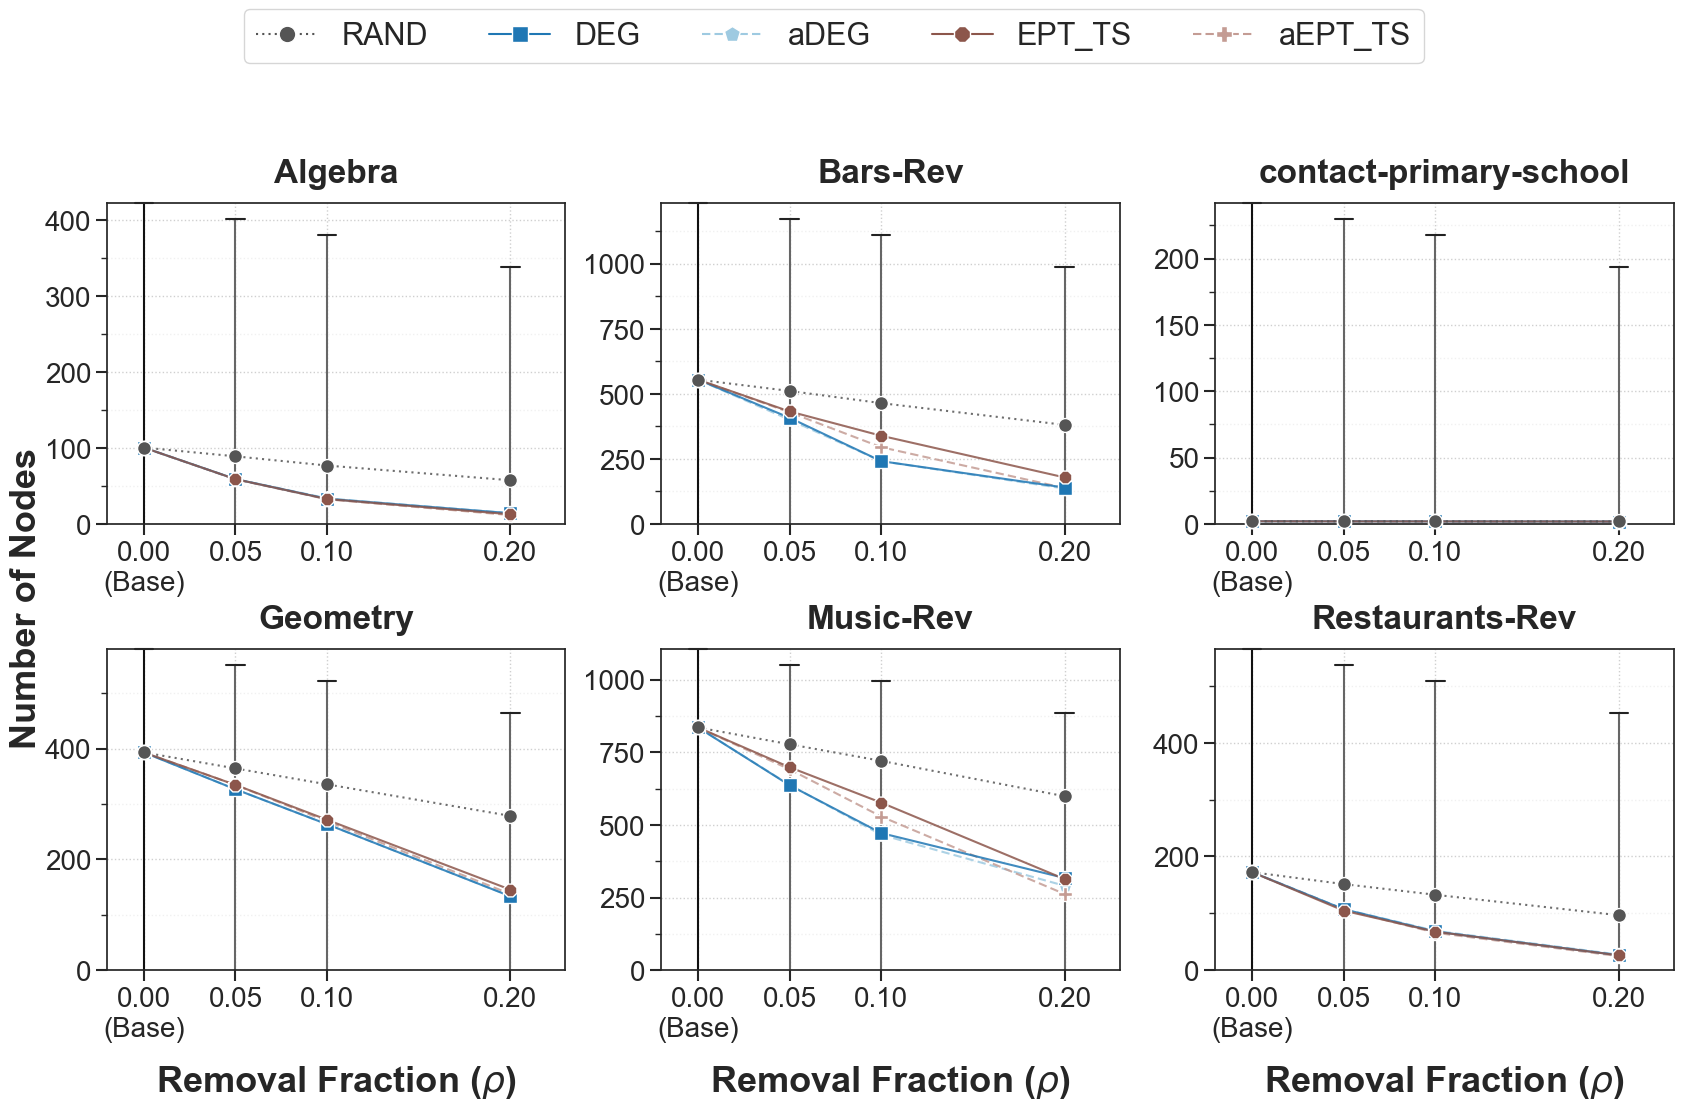

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

# ==========================================
# 1. Aesthetics (Using your globally defined style maps)
# ==========================================
sns.set_theme(style="white") 

# List of all active evaluation strategies to be plotted as trendlines
local_strategies = [
    'RAND', 
    'DEG', 'aDEG', 
    # 'HDEG', 'aHDEG', 'AHS', 'aAHS', 
    'EPT_TS', 'aEPT_TS'
    # 'EPT_BIS', 'aEPT_BIS', 'EPT_BOS', 'aEPT_BOS', 'EPT_TS', 'aEPT_TS'
]

# Separate strategies into categories for strict layer stacking
one_shot_strategies = [s for s in local_strategies if s not in ['RAND'] and not s.startswith('a')]
adaptive_strategies = [s for s in local_strategies if s.startswith('a')]

# ==========================================
# 2. Data Filtering & Baseline Integration
# ==========================================
# 2a. Filter heuristic strategies from selected_df (excluding RAND)
heuristic_strategies = [s for s in local_strategies if s != 'RAND']
plot_heuristics = selected_df[
    (selected_df['community_config'] == 'gt') &
    (selected_df['timestep'] == 25) &
    (selected_df['strategy'].isin(heuristic_strategies))
].copy()

# 2b. Filter RAND strategy from your dedicated RAND dataframe
plot_rand = RAND[
    (RAND['timestep'] == 25) &
    (RAND['strategy'] == 'RAND')
].copy()

# Combine active strategies into a single plotting base
plot_df = pd.concat([plot_heuristics, plot_rand], ignore_index=True)

dataset_max_capacities = {}
baseline_rows = []

# 2c. Extract baseline characteristics from your dedicated EMPTY dataframe
for dataset, group in plot_df.groupby('dataset'):
    empty_match = EMPTY[
        (EMPTY['dataset'] == dataset) &
        (EMPTY['timestep'] == 25) &
        (EMPTY['strategy'] == 'EMPTY_STRATEGY')
    ]
    
    if not empty_match.empty:
        # Under EMPTY_STRATEGY (p=0.0), remaining nodes represent full original capacity N0
        n0 = empty_match['remaining_nodes'].iloc[0]
        abs_infected_base = empty_match['mean_infected'].iloc[0]
    else:
        # Robust fallback calculator if a specific dataset split is missing in EMPTY
        sample_row = group.iloc[0]
        n0 = sample_row['remaining_nodes'] / (1 - sample_row['p']) if sample_row['p'] != 1.0 else sample_row['remaining_nodes']
        abs_infected_base = sample_row['mean_infected']
        
    dataset_max_capacities[dataset] = n0
    
    # Inject an artificial p=0.0 starting point for each active strategy
    for strategy in local_strategies:
        baseline_rows.append({
            'dataset': dataset,
            'strategy': strategy,
            'p': 0.0,
            'remaining_nodes': n0,
            'mean_infected': abs_infected_base,
            'community_config': 'ground_truth',
            'timestep': 25
        })
        
    # Inject an explicit point for EMPTY_STRATEGY at p=0.0 to plot independently
    baseline_rows.append({
        'dataset': dataset,
        'strategy': 'EMPTY_STRATEGY',
        'p': 0.0,
        'remaining_nodes': n0,
        'mean_infected': abs_infected_base,
        'community_config': 'ground_truth',
        'timestep': 25
    })

# Combine everything into the final plotting dataframe
plot_df = pd.concat([plot_df, pd.DataFrame(baseline_rows)], ignore_index=True)

# ==========================================
# 3. Custom Drawing Function
# ==========================================
def draw_capacity_curves(data, **kwargs):
    ax = plt.gca()
    unique_ps = sorted(data['p'].unique())
    
    # LAYER 1: Capacity trunks and T-caps (Lowest structural layer)
    for p_val in unique_ps:
        sub_data = data[data['p'] == p_val]
        if not sub_data.empty:
            rem_nodes = sub_data['remaining_nodes'].iloc[0]
            line_color = '#111111' if p_val == 0.0 else '#666666'
            
            ax.vlines(x=p_val, ymin=0, ymax=rem_nodes, colors=line_color, linewidth=1.5, zorder=1, clip_on=False)
            ax.plot([p_val - 0.005, p_val + 0.005], [rem_nodes, rem_nodes], color='#222222', linewidth=1.5, zorder=1, clip_on=False)
            
    # LAYER 2: Adaptive Strategies (zorder 3 and 4)
    for strategy in adaptive_strategies:
        strat_data = data[data['strategy'] == strategy].sort_values('p')
        if not strat_data.empty:
            dash_style = dashes.get(strategy, [])
            
            line, = ax.plot(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], linewidth=1.5, alpha=0.85, zorder=3, clip_on=False
            )
            if len(dash_style) > 0:
                line.set_dashes(dash_style)
                
            ax.scatter(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], marker=markers[strategy], s=100,
                edgecolor='white', linewidth=1.0, alpha=1.0, zorder=4, clip_on=False
            )
            
    # LAYER 3: One-Shot Strategies (zorder 5 and 6 -> Renders on top of Adaptive)
    for strategy in one_shot_strategies:
        strat_data = data[data['strategy'] == strategy].sort_values('p')
        if not strat_data.empty:
            dash_style = dashes.get(strategy, [])
            
            line, = ax.plot(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], linewidth=1.5, alpha=0.85, zorder=5, clip_on=False
            )
            if len(dash_style) > 0:
                line.set_dashes(dash_style)
                
            ax.scatter(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], marker=markers[strategy], s=100,
                edgecolor='white', linewidth=1.0, alpha=1.0, zorder=6, clip_on=False
            )
            
    # LAYER 4: RAND Baseline (zorder 7 and 8 -> On top of all heuristics everywhere)
    rand_data = data[data['strategy'] == 'RAND'].sort_values('p')
    if not rand_data.empty:
        dash_style = dashes.get('RAND', [])
        
        line, = ax.plot(
            rand_data['p'], rand_data['mean_infected'], 
            color=palette['RAND'], linewidth=1.5, alpha=0.85, zorder=7, clip_on=False
        )
        if len(dash_style) > 0:
            line.set_dashes(dash_style)
            
        ax.scatter(
            rand_data['p'], rand_data['mean_infected'], 
            color=palette['RAND'], marker=markers['RAND'], s=100,
            edgecolor='white', linewidth=1.0, alpha=1.0, zorder=8, clip_on=False
        )
            
    # LAYER 5: EMPTY_STRATEGY point at origin (zorder 9 -> Absolute topmost element at p=0.0)
    empty_data = data[data['strategy'] == 'EMPTY_STRATEGY']
    if not empty_data.empty:
        ax.scatter(
            empty_data['p'], empty_data['mean_infected'], 
            color=palette['RAND'], marker=markers['RAND'], s=100,
            edgecolor='white', linewidth=1.0, alpha=1.0, zorder=9, clip_on=False
        )

# ==========================================
# 4. Multi-Panel Layout & Formatting
# ==========================================
g = sns.FacetGrid(
    data=plot_df, col='dataset', col_wrap=3, height=5.2, aspect=1.1, sharey=False, sharex=False
)
g.map_dataframe(draw_capacity_curves)

# Typography Scales
g.set_axis_labels("Removal Fraction ($\\rho$)", "", fontsize=26, weight='bold', labelpad=15)
g.set_titles(col_template="{col_name}", size=24, weight='bold', pad=15) 
g.fig.supylabel("Number of Nodes", fontsize=26, weight='bold')

# Axis Controls & Tick Configurations
for ax in g.axes.flat:
    current_title = ax.get_title()
    
    # Gridlines
    ax.grid(True, which='major', linestyle=':', alpha=0.6, color='#b0b0b0')
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
    ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='#d0d0d0')
    
    # Spines
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    
    # Ticks Setup
    ax.tick_params(axis='both', which='major', labelsize=20, left=True, bottom=True, length=8, width=1.5)
    ax.tick_params(axis='y', which='minor', left=True, length=4, width=1.0) 
    
    # X-Axis intervals
    ax.set_xticks([0.0, 0.05, 0.10, 0.20])
    ax.set_xticklabels(['0.00\n(Base)', '0.05', '0.10', '0.20'], fontsize=20)
    ax.set_xlim(-0.02, 0.23) 
    
    # Match network ceilings precisely
    if current_title in dataset_max_capacities:
        ax.set_ylim(bottom=0, top=dataset_max_capacities[current_title])
    else:
        ax.set_ylim(bottom=0)

# ==========================================
# 5. Legend Generation & Final Layout
# ==========================================
legend_handles = []
for s in local_strategies:
    handle = plt.Line2D(
        [0], [0], marker=markers[s], color=palette[s], markerfacecolor=palette[s], 
        markeredgecolor='white', markeredgewidth=1.0, markersize=12, linewidth=1.5,
        label=s
    )
    if len(dashes.get(s, [])) > 0:
        handle.set_dashes(dashes[s])
    else:
        handle.set_linestyle('-')
    legend_handles.append(handle)

g.figure.legend(
    handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.0),    
    ncol=5, frameon=True, fontsize=22, columnspacing=2.0
)

plt.tight_layout()
g.fig.subplots_adjust(top=0.88) 

plt.show()

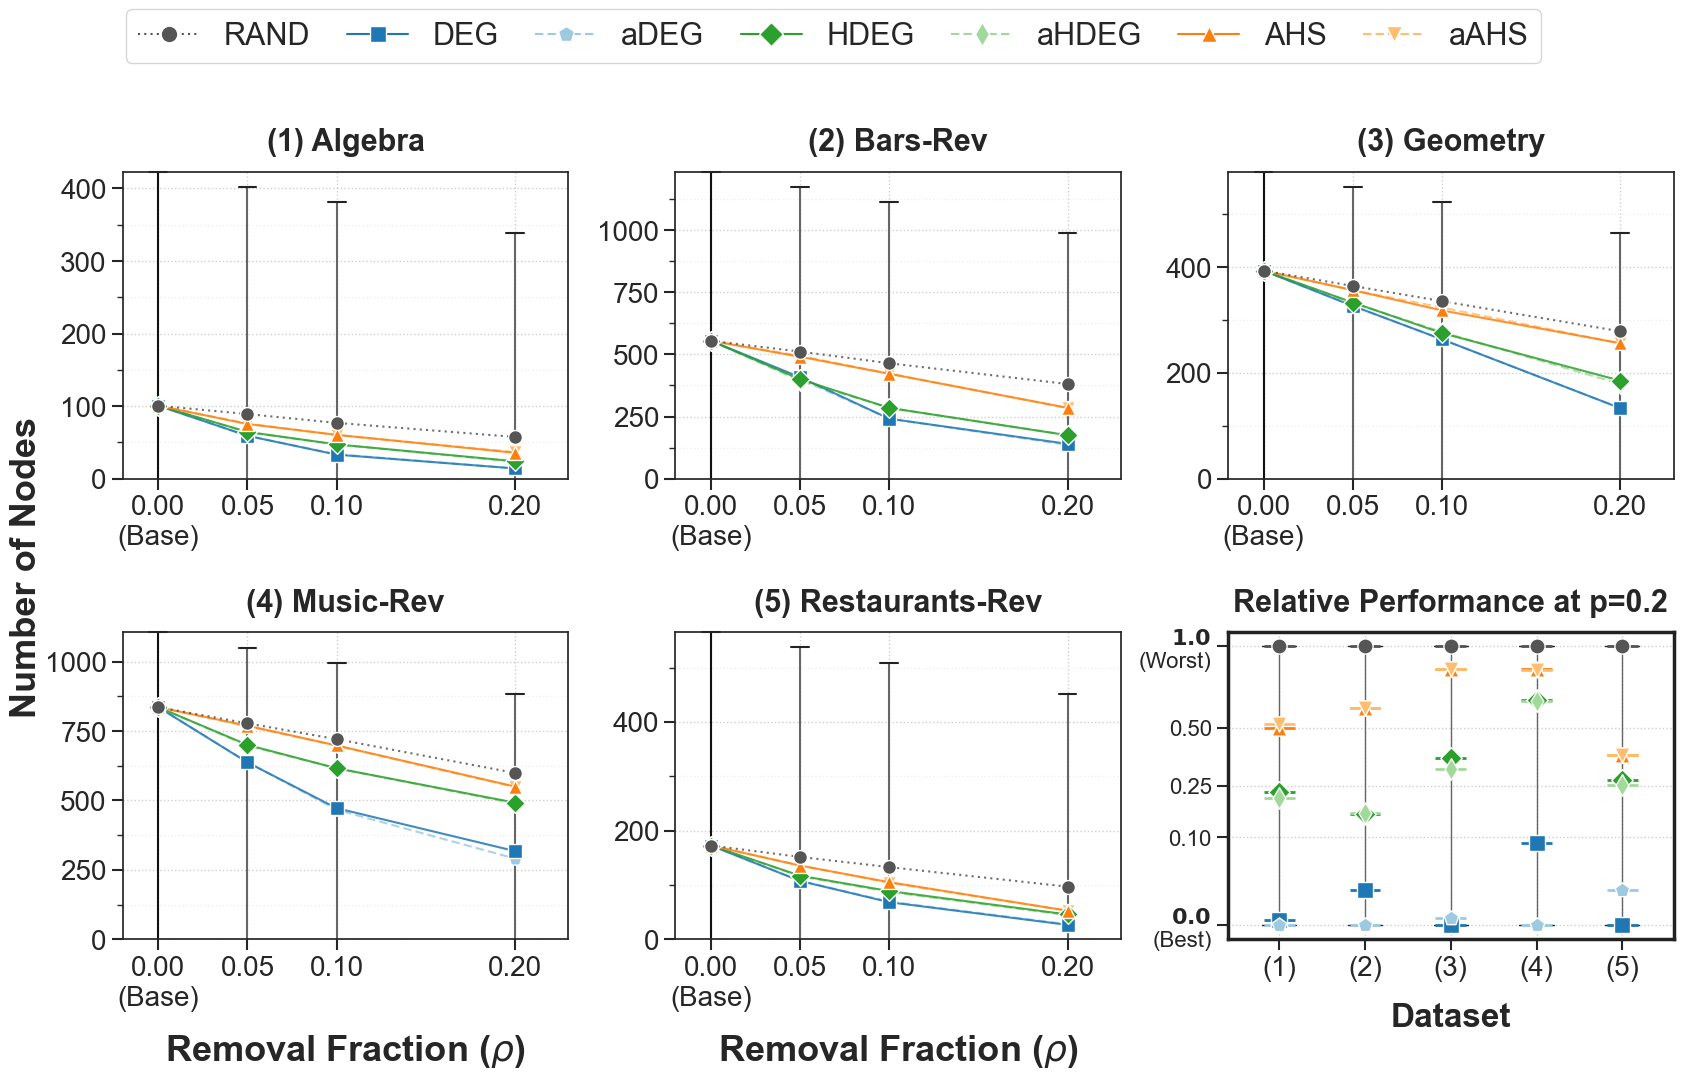

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

# ==========================================
# 1. Aesthetics & Setup
# ==========================================
sns.set_theme(style="white") 

# local_strategies = ['RAND', 'DEG', 'aDEG', 'HDEG', 'aHDEG', 'AHS', 'aAHS']
local_strategies = ['RAND', 'DEG', 'aDEG', 'EPT_TS', 'aEPT_TS']
one_shot_strategies = [s for s in local_strategies if s not in ['RAND'] and not s.startswith('a')]
adaptive_strategies = [s for s in local_strategies if s.startswith('a')]

# ==========================================
# 2. Data Filtering & Baseline Integration
# ==========================================
active_datasets = [d for d in selected_df['dataset'].unique() if d != 'contact-primary-school']
dataset_mapping = {d: f"({i+1}) {d}" for i, d in enumerate(active_datasets)}

heuristic_strategies = [s for s in local_strategies if s != 'RAND']
plot_heuristics = selected_df[
    (selected_df['community_config'] == 'gt') &
    (selected_df['timestep'] == 25) &
    (selected_df['strategy'].isin(heuristic_strategies)) &
    (selected_df['dataset'].isin(active_datasets))
].copy()

plot_rand = RAND[
    (RAND['timestep'] == 25) &
    (RAND['strategy'] == 'RAND') &
    (RAND['dataset'].isin(active_datasets))
].copy()

base_df = pd.concat([plot_heuristics, plot_rand], ignore_index=True)

dataset_max_capacities = {}
baseline_rows = []

for dataset, group in base_df.groupby('dataset'):
    empty_match = EMPTY[
        (EMPTY['dataset'] == dataset) &
        (EMPTY['timestep'] == 25) &
        (EMPTY['strategy'] == 'EMPTY_STRATEGY')
    ]
    
    if not empty_match.empty:
        n0 = empty_match['remaining_nodes'].iloc[0]
        abs_infected_base = empty_match['mean_infected'].iloc[0]
    else:
        sample_row = group.iloc[0]
        n0 = sample_row['remaining_nodes'] / (1 - sample_row['p']) if sample_row['p'] != 1.0 else sample_row['remaining_nodes']
        abs_infected_base = sample_row['mean_infected']
        
    display_title = dataset_mapping[dataset]
    dataset_max_capacities[display_title] = n0
    
    for strategy in local_strategies:
        baseline_rows.append({
            'dataset': dataset, 'strategy': strategy, 'p': 0.0,
            'remaining_nodes': n0, 'mean_infected': abs_infected_base,
            'community_config': 'ground_truth', 'timestep': 25
        })
    baseline_rows.append({
        'dataset': dataset, 'strategy': 'EMPTY_STRATEGY', 'p': 0.0,
        'remaining_nodes': n0, 'mean_infected': abs_infected_base,
        'community_config': 'ground_truth', 'timestep': 25
    })

plot_df = pd.concat([base_df, pd.DataFrame(baseline_rows)], ignore_index=True)
plot_df['dataset'] = plot_df['dataset'].map(dataset_mapping)

# --------------------------------------------------------
# TRANSFORM: Min-Max + Power Transform to de-compress clusters
# --------------------------------------------------------
p20_summary_data = plot_df[plot_df['p'] == 0.20].copy()

normalized_summary_rows = []
for d_name, d_group in p20_summary_data.groupby('dataset'):
    strat_group = d_group[d_group['strategy'].isin(local_strategies)]
    
    if not strat_group.empty:
        min_inf = strat_group['mean_infected'].min()
        max_inf = strat_group['mean_infected'].max()
        val_range = max_inf - min_inf if max_inf != min_inf else 1.0
        
        for _, row in strat_group.iterrows():
            row_copy = row.copy()
            norm_val = (row['mean_infected'] - min_inf) / val_range
            row_copy['norm_infected'] = np.power(norm_val, 0.5)
            normalized_summary_rows.append(row_copy)

p20_normalized_df = pd.DataFrame(normalized_summary_rows)

summary_panel_title = "Relative Performance at p=0.2"
plot_df['dataset'] = pd.Categorical(
    plot_df['dataset'], 
    categories=list(dataset_mapping.values()) + [summary_panel_title]
)

# ==========================================
# 3. Custom Drawing Function
# ==========================================
def draw_capacity_curves(data, **kwargs):
    ax = plt.gca()
    current_title = ax.get_title()
    if current_title == summary_panel_title:
        return
        
    unique_ps = sorted(data['p'].unique())
    
    for p_val in unique_ps:
        sub_data = data[data['p'] == p_val]
        if not sub_data.empty:
            rem_nodes = sub_data['remaining_nodes'].iloc[0]
            line_color = '#111111' if p_val == 0.0 else '#666666'
            ax.vlines(x=p_val, ymin=0, ymax=rem_nodes, colors=line_color, linewidth=1.5, zorder=1, clip_on=False)
            ax.plot([p_val - 0.005, p_val + 0.005], [rem_nodes, rem_nodes], color='#222222', linewidth=1.5, zorder=1, clip_on=False)
            
    for strategy in adaptive_strategies:
        strat_data = data[data['strategy'] == strategy].sort_values('p')
        if not strat_data.empty:
            line, = ax.plot(strat_data['p'], strat_data['mean_infected'], color=palette[strategy], linewidth=1.5, alpha=0.85, zorder=3, clip_on=False)
            if len(dashes.get(strategy, [])) > 0: line.set_dashes(dashes[strategy])
            ax.scatter(strat_data['p'], strat_data['mean_infected'], color=palette[strategy], marker=markers[strategy], s=100, edgecolor='white', linewidth=1.0, alpha=1.0, zorder=4, clip_on=False)
            
    for strategy in one_shot_strategies:
        strat_data = data[data['strategy'] == strategy].sort_values('p')
        if not strat_data.empty:
            line, = ax.plot(strat_data['p'], strat_data['mean_infected'], color=palette[strategy], linewidth=1.5, alpha=0.85, zorder=5, clip_on=False)
            if len(dashes.get(strategy, [])) > 0: line.set_dashes(dashes[strategy])
            ax.scatter(strat_data['p'], strat_data['mean_infected'], color=palette[strategy], marker=markers[strategy], s=100, edgecolor='white', linewidth=1.0, alpha=1.0, zorder=6, clip_on=False)
            
    rand_data = data[data['strategy'] == 'RAND'].sort_values('p')
    if not rand_data.empty:
        line, = ax.plot(rand_data['p'], rand_data['mean_infected'], color=palette['RAND'], linewidth=1.5, alpha=0.85, zorder=7, clip_on=False)
        if len(dashes.get('RAND', [])) > 0: line.set_dashes(dashes['RAND'])
        ax.scatter(rand_data['p'], rand_data['mean_infected'], color=palette['RAND'], marker=markers['RAND'], s=100, edgecolor='white', linewidth=1.0, alpha=1.0, zorder=8, clip_on=False)
            
    empty_data = data[data['strategy'] == 'EMPTY_STRATEGY']
    if not empty_data.empty:
        ax.scatter(empty_data['p'], empty_data['mean_infected'], color=palette['RAND'], marker=markers['RAND'], s=100, edgecolor='white', linewidth=1.0, alpha=1.0, zorder=9, clip_on=False)

# ==========================================
# 4. Multi-Panel Layout & Formatting
# ==========================================
g = sns.FacetGrid(
    data=plot_df, col='dataset', col_wrap=3, height=5.2, aspect=1.1, sharey=False, sharex=False
)
g.map_dataframe(draw_capacity_curves)

g.set_axis_labels("Removal Fraction ($\\rho$)", "", fontsize=26, weight='bold', labelpad=15)
g.set_titles(col_template="{col_name}", size=22, weight='bold', pad=15) 
g.fig.supylabel("Number of Nodes", fontsize=26, weight='bold')

for ax in g.axes.flat:
    current_title = ax.get_title()
    
    # Base setup for standard plots (Standard border width=1.5)
    ax.grid(True, which='major', linestyle=':', alpha=0.6, color='#b0b0b0')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.tick_params(axis='both', which='major', labelsize=20, left=True, bottom=True, length=8, width=1.5)
    
    # --------------------------------------------------------
    # IF CUSTOM SUMMARY AXIS: Thicker Bounding Border Only
    # --------------------------------------------------------
    if current_title == summary_panel_title:
        # Returned to standard theme background
        ax.set_facecolor('#ffffff') 
        ax.yaxis.set_minor_locator(plt.NullLocator())
        
        # Thicken the bounding box spines to emphasize the summary enclosure
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.5)
            spine.set_color('#222222')
            
        x_positions = np.arange(1, 6)
        ordered_datasets = sorted(list(dataset_mapping.values()))
        
        for idx, d_name in enumerate(ordered_datasets):
            x_pos = x_positions[idx]
            d_subset = p20_normalized_df[p20_normalized_df['dataset'] == d_name]
            
            if not d_subset.empty:
                # Restored clean vertical trunk lines
                ax.vlines(x=x_pos, ymin=0.0, ymax=1.0, colors='#666666', linewidth=1.0, zorder=1)
                ax.plot([x_pos - 0.2, x_pos + 0.2], [0.0, 0.0], color='#222222', linewidth=1.0, zorder=1)
                ax.plot([x_pos - 0.2, x_pos + 0.2], [1.0, 1.0], color='#222222', linewidth=1.0, zorder=1)
                
                for strategy in local_strategies:
                    strat_row = d_subset[d_subset['strategy'] == strategy]
                    if not strat_row.empty:
                        y_val = strat_row['norm_infected'].iloc[0]
                        
                        ax.hlines(
                            y=y_val, xmin=x_pos - 0.18, xmax=x_pos + 0.18, 
                            colors=palette[strategy], linewidth=2.0, zorder=4, clip_on=False
                        )
                        
                        ax.scatter(
                            x_pos, y_val, color=palette[strategy], marker=markers[strategy], 
                            s=120, edgecolor='white', linewidth=1.0, zorder=5, clip_on=False
                        )
        
        ax.set_xlabel("Dataset", fontsize=24, weight='bold', labelpad=15)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(['(1)', '(2)', '(3)', '(4)', '(5)'], fontsize=20)
        ax.set_xlim(0.4, 5.6)
        ax.set_ylim(-0.05, 1.05)
        
        target_milestones = [0.0, 0.1, 0.25, 0.5, 1.0]
        tick_positions = [np.sqrt(val) for val in target_milestones]
        
        ax.set_yticks(tick_positions) 
        ax.set_yticklabels([
            r'$\mathbf{0.0}$' + '\n(Best)', 
            '0.10', 
            '0.25', 
            '0.50', 
            r'$\mathbf{1.0}$' + '\n(Worst)'
        ], fontsize=16)
        
    else:
        # Standard Axis Setup
        ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
        ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='#d0d0d0')
        ax.tick_params(axis='y', which='minor', left=True, length=4, width=1.0) 
        
        ax.set_xticks([0.0, 0.05, 0.10, 0.20])
        ax.set_xticklabels(['0.00\n(Base)', '0.05', '0.10', '0.20'], fontsize=20)
        ax.set_xlim(-0.02, 0.23) 
        
        if current_title in dataset_max_capacities:
            ax.set_ylim(bottom=0, top=dataset_max_capacities[current_title])
        else:
            ax.set_ylim(bottom=0)

# ==========================================
# 5. Legend Generation & Final Layout
# ==========================================
legend_handles = []
for s in local_strategies:
    handle = plt.Line2D(
        [0], [0], marker=markers[s], color=palette[s], markerfacecolor=palette[s], 
        markeredgecolor='white', markeredgewidth=1.0, markersize=12, linewidth=1.5,
        label=s
    )
    if len(dashes.get(s, [])) > 0: handle.set_dashes(dashes[s])
    else: handle.set_linestyle('-')
    legend_handles.append(handle)

g.figure.legend(
    handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.97),    
    ncol=8, frameon=True, fontsize=22, columnspacing=1.2
)

g.fig.tight_layout(h_pad=3.5) 
g.fig.subplots_adjust(top=0.88, hspace=0.50) 

plt.show()

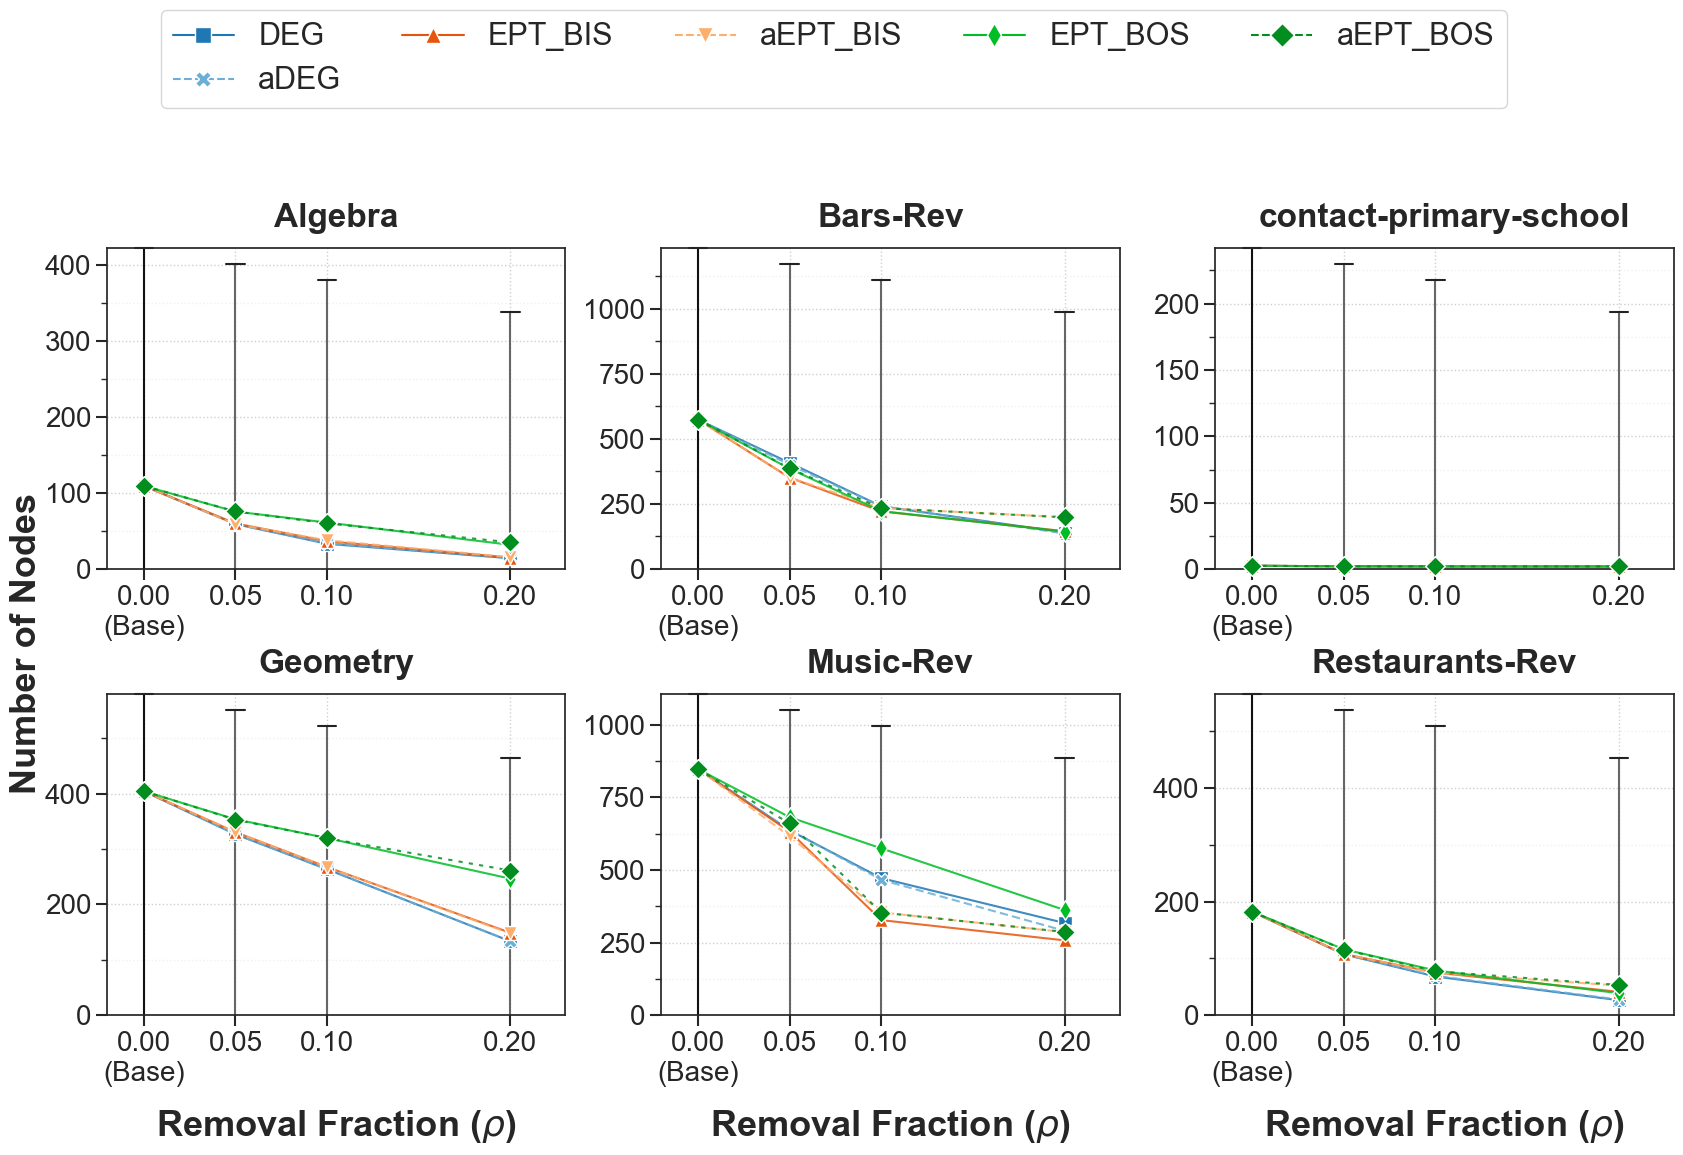

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

selected_df = master_df

# ==========================================
# 1. Aesthetics (Reverted to default fonts)
# ==========================================
sns.set_theme(style="white") 

palette = {
    'RAND': '#4d4d4d', 'DEG': '#1f77b4', 'aDEG': '#6baed6', 'EPT_BIS': '#e6550d', 'aEPT_BIS': '#fdae6b', 'EPT_BOS' : "#00bd26", 'aEPT_BOS' : "#028e1e"
}

markers = {
    'RAND': 'o', 'DEG': 's', 'aDEG': 'X', 'EPT_BIS': '^', 'aEPT_BIS': 'v', 'EPT_BOS' : 'd', 'aEPT_BOS' : 'D',
}

dashes = {
    'RAND': (1, 2), 'DEG': [], 'aDEG': (4, 2), 'EPT_BIS': [], 'aEPT_BIS': (4, 2), 'EPT_BOS' : [], 'aEPT_BOS' : (2, 3), 
}

# ==========================================
# 2. Data Filtering & Baseline Integration
# ==========================================
local_strategies = ['DEG', 'aDEG', 'EPT_BIS', 'aEPT_BIS', 'EPT_BOS', 'aEPT_BOS']

# Filter Section 5.1 data
plot_df = selected_df[
    (selected_df['community_config'] == 'gt') &
    (selected_df['timestep'] == 25) &
    (selected_df['strategy'].isin(local_strategies))
].copy()

# Extract baseline percentages
baseline_pcts = empty_df.set_index('Unnamed: 0').iloc[0].to_dict()

dataset_max_capacities = {}
baseline_rows = []

for dataset, group in plot_df.groupby('dataset'):
    sample_row = group.iloc[0]
    # Reverse engineer original network capacity
    n0 = sample_row['remaining_nodes'] / (1 - sample_row['p'])
    dataset_max_capacities[dataset] = n0
    
    # Calculate absolute baseline infection
    pct = baseline_pcts.get(dataset, 0)
    abs_infected_base = n0 * (pct / 100.0)
    
    for strategy in local_strategies:
        baseline_rows.append({
            'dataset': dataset,
            'strategy': strategy,
            'p': 0.0,
            'remaining_nodes': n0,
            'mean_infected': abs_infected_base,
            'community_config': 'ground_truth',
            'timestep': 25
        })

# Combine into a single plotting dataframe
plot_df = pd.concat([plot_df, pd.DataFrame(baseline_rows)], ignore_index=True)

# ==========================================
# 3. Custom Drawing Function
# ==========================================
def draw_capacity_curves(data, **kwargs):
    ax = plt.gca()
    unique_ps = sorted(data['p'].unique())
    
    # Draw capacity trunks and T-caps
    for p_val in unique_ps:
        sub_data = data[data['p'] == p_val]
        if not sub_data.empty:
            rem_nodes = sub_data['remaining_nodes'].iloc[0]
            
            line_color = '#111111' if p_val == 0.0 else '#666666'
            
            ax.vlines(x=p_val, ymin=0, ymax=rem_nodes, colors=line_color, linewidth=1.5, zorder=1, clip_on=False)
            ax.plot([p_val - 0.005, p_val + 0.005], [rem_nodes, rem_nodes], color='#222222', linewidth=1.5, zorder=1, clip_on=False)
            
    # Draw trend lines and markers
    for strategy in local_strategies:
        strat_data = data[data['strategy'] == strategy].sort_values('p')
        if not strat_data.empty:
            dash_style = dashes.get(strategy, [])
            
            line, = ax.plot(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], linewidth=1.5, alpha=0.85, zorder=3, clip_on=False
            )
            if len(dash_style) > 0:
                line.set_dashes(dash_style)
                
            ax.scatter(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], marker=markers[strategy], s=100,
                edgecolor='white', linewidth=1.0, alpha=1.0, zorder=4, clip_on=False
            )

# ==========================================
# 4. Multi-Panel Layout & Formatting
# ==========================================
g = sns.FacetGrid(
    data=plot_df, col='dataset', col_wrap=3, height=5.2, aspect=1.1, sharey=False, sharex=False
)
g.map_dataframe(draw_capacity_curves)

# INCREASED FONT SIZES for Axis Labels and Titles
g.set_axis_labels("Removal Fraction ($\\rho$)", "", fontsize=26, weight='bold', labelpad=15)
g.set_titles(col_template="{col_name}", size=24, weight='bold', pad=15) 
g.fig.supylabel("Number of Nodes", fontsize=26, weight='bold')

# Axis Controls & Tick Fixes
for ax in g.axes.flat:
    current_title = ax.get_title()
    
    # Gridlines
    ax.grid(True, which='major', linestyle=':', alpha=0.6, color='#b0b0b0')
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
    ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='#d0d0d0')
    
    # Spines
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    
    # Fix Ticks: Heavy major ticks, light minor ticks (INCREASED labelsize to 20)
    ax.tick_params(axis='both', which='major', labelsize=20, left=True, bottom=True, length=8, width=1.5)
    ax.tick_params(axis='y', which='minor', left=True, length=4, width=1.0) 
    
    # X-Axis limits and explicit ticks (INCREASED xticklabel fontsize to 20)
    ax.set_xticks([0.0, 0.05, 0.10, 0.20])
    ax.set_xticklabels(['0.00\n(Base)', '0.05', '0.10', '0.20'], fontsize=20)
    ax.set_xlim(-0.02, 0.23) 
    
    # Set exact ceiling
    if current_title in dataset_max_capacities:
        ax.set_ylim(bottom=0, top=dataset_max_capacities[current_title])
    else:
        ax.set_ylim(bottom=0)

# ==========================================
# 5. Legend Generation & Final Layout
# ==========================================
legend_handles = [
    plt.Line2D(
        [0], [0], marker=markers[s], color=palette[s], markerfacecolor=palette[s], 
        markeredgecolor='white', markeredgewidth=1.0, markersize=12, linewidth=1.5,
        linestyle='--' if len(dashes[s]) > 0 else '-', label=s
    ) for s in local_strategies
]

# INCREASED FONT SIZE for Legend (fontsize=22)
g.figure.legend(
    handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.0),    
    ncol=5, frameon=True, fontsize=22, columnspacing=2.0
)

plt.tight_layout()
g.fig.subplots_adjust(top=0.88)   

plt.show()